# Predicting Power Efficiency using Advanced Regression Analysis

## Project Objective
Build and compare regression models to predict **Power_Efficiency** from numerical sensor/operational features and categorical device/environment variables.

### Required workflow
1. Data collection and initial inspection
2. Data cleaning: missing values and outlier treatment
3. Exploratory data analysis (EDA)
4. Feature engineering
5. Categorical encoding
6. Feature scaling
7. Model development:
   - Linear Regression
   - Decision Tree Regressor
   - Random Forest Regressor
   - Gradient Boosting Regressor
   - XGBoost Regressor
8. Evaluation using RMSE and R²
9. 5-fold cross-validation
10. Statistical hypothesis testing and evidence-based observations
11. Results comparison and actionable insights

> **Performance target:** R² ≥ 0.85 is used as the project's requested 85% predictive-performance threshold. R² is not classification accuracy; it represents the proportion of target variance explained by the model.


## Dataset
The notebook expects the uploaded dataset to be available as:

`/mnt/data/Power_Dataset.csv`

Expected columns:
- `Feature_1` ... `Feature_15`
- `Device_Type`
- `Environment`
- `Power_Efficiency`

The notebook is written so that it can also be run locally by changing `DATA_PATH`.


In [ ]:
# 1. Imports and reproducibility
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "dataset.csv"

# If running locally, uncomment and change:
# DATA_PATH = "Power_Dataset.csv"

try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError(
        "XGBoost is required. Install it with: pip install xgboost"
    )

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [6]:
# 2. Load the dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (10000, 18)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Device_Type,Environment,Power_Efficiency
0,-1.529631,-0.229829,-1.133380,-0.032698,-0.023546,0.190398,-0.044578,1.617860,0.422554,0.757900,0.135087,1.771565,0.674063,-0.532892,1.238310,Controller,Industrial,26.110262
1,-0.489570,-0.088583,-0.791501,-0.899364,1.157639,-0.824769,0.217582,-0.045827,-0.145721,1.664233,1.172259,-1.033515,0.843380,0.200462,-2.538103,Gateway,Residential,-55.054269
2,-0.704766,-0.672018,-2.769177,-0.377164,0.059146,-2.021345,0.542038,0.848163,-2.301764,-0.284346,-0.193142,-1.512294,1.569515,-0.010277,-0.460736,Sensor,Industrial,-221.579909
3,0.140443,1.279102,-0.309443,-0.488906,1.648295,-2.332286,-0.350755,-0.104239,-1.211797,-0.458519,-1.765805,1.107642,-0.822441,0.619504,1.391085,Controller,Residential,33.307775
4,0.384900,0.183544,-1.207033,0.755742,-0.582918,-2.475565,0.274686,-0.136788,0.309404,-1.805481,-0.647693,0.038536,2.526582,1.172795,2.056307,Controller,Residential,122.417840


In [7]:
# 3. Initial inspection
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = 100 * missing["missing_count"] / len(df)
display(missing[missing["missing_count"] > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe().T)


Data types:


,dtype
Feature_1,float64
Feature_2,float64
Feature_3,float64
Feature_4,float64
Feature_5,float64
Feature_6,float64
Feature_7,float64
Feature_8,float64
Feature_9,float64
Feature_10,float64



Missing values:


,missing_count,missing_percent
Feature_3,1000,10.0
Feature_7,1000,10.0
Feature_11,1000,10.0



Duplicate rows: 0

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Feature_1,10000.0,-0.014002,1.010656,-4.295391,-0.692064,-0.009793,0.659427,3.926238
Feature_2,10000.0,-0.001822,1.020176,-3.836656,-0.698058,-0.002310,0.684168,3.471549
Feature_3,9000.0,0.019152,1.003679,-4.465604,-0.661866,0.018377,0.706945,3.529055
Feature_4,10000.0,-0.010948,0.996653,-3.782616,-0.685835,-0.008942,0.659482,3.464714
Feature_5,10000.0,0.007448,1.201723,-13.982375,-0.679879,0.022008,0.703068,13.072332
Feature_6,10000.0,-0.004365,0.999782,-3.999332,-0.675714,-0.004020,0.664730,4.479084
Feature_7,9000.0,0.009879,0.998956,-3.856375,-0.664008,0.012845,0.696226,4.202026
Feature_8,10000.0,-0.014970,0.997203,-3.940008,-0.699164,-0.012194,0.661964,3.712795
Feature_9,10000.0,-0.000547,0.983976,-3.464809,-0.667472,0.004271,0.678214,3.760155
Feature_10,10000.0,0.006924,1.000311,-4.157734,-0.665235,0.010218,0.671012,3.852731


## 4. Data Quality Assessment

### Missing-value hypothesis
**H0:** The numerical predictors contain no missing observations.  
**H1:** At least one predictor contains missing observations.

The missing-value table above provides direct evidence. Missing values are handled inside the modeling pipeline using median imputation for numerical features and most-frequent imputation for categorical features. This avoids leakage because imputation parameters are learned from the training folds only.

### Outlier hypothesis
**H0:** Feature_5 does not contain unusual/extreme observations relative to its central distribution.  
**H1:** Feature_5 contains statistically unusual observations.

Feature_5 is explicitly described as the feature containing outliers. We therefore quantify IQR outliers before modeling and remove only the identified Feature_5 outlier rows. The target is not filtered using its own value because removing extreme target values can artificially improve a model by changing the prediction problem.


In [8]:
# 5. Outlier detection using the IQR rule
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_report = []
for col in [f"Feature_{i}" for i in range(1, 16)]:
    s = df[col].dropna()
    lower, upper = iqr_bounds(s)
    count = ((s < lower) | (s > upper)).sum()
    outlier_report.append([col, lower, upper, int(count), 100 * count / len(s)])

outlier_report = pd.DataFrame(
    outlier_report,
    columns=["feature", "lower_bound", "upper_bound", "outlier_count", "outlier_percent"]
)
display(outlier_report.sort_values("outlier_count", ascending=False))


,feature,lower_bound,upper_bound,outlier_count,outlier_percent
4,Feature_5,-2.754299,2.777488,168,1.680000
0,Feature_1,-2.719299,2.686662,81,0.810000
10,Feature_11,-2.645342,2.627260,81,0.900000
9,Feature_10,-2.669607,2.675384,80,0.800000
1,Feature_2,-2.771398,2.757507,76,0.760000
5,Feature_6,-2.686380,2.675396,73,0.730000
8,Feature_9,-2.686001,2.696744,73,0.730000
14,Feature_15,-2.657798,2.666441,73,0.730000
13,Feature_14,-2.672904,2.694748,68,0.680000
11,Feature_12,-2.708643,2.713816,64,0.640000


In [9]:
# 6. Remove the documented Feature_5 outliers
feature5_lower, feature5_upper = iqr_bounds(df["Feature_5"])
feature5_outlier_mask = (
    (df["Feature_5"] < feature5_lower) |
    (df["Feature_5"] > feature5_upper)
)

print("Feature_5 lower IQR bound:", feature5_lower)
print("Feature_5 upper IQR bound:", feature5_upper)
print("Rows identified as Feature_5 outliers:", feature5_outlier_mask.sum())

df_clean = df.loc[~feature5_outlier_mask].copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)


Feature_5 lower IQR bound: -2.7542986931912234
Feature_5 upper IQR bound: 2.7774875101885503
Rows identified as Feature_5 outliers: 168
Original shape: (10000, 18)
Cleaned shape: (9832, 18)


# 7. Exploratory Data Analysis (EDA)

EDA is used to understand:
- target distribution and spread;
- numerical feature distributions;
- categorical group differences;
- correlations and possible multicollinearity;
- relationships between predictors and Power_Efficiency;
- whether the stated data-quality problems are visible in the data.

**Evidence-based observation:** the numerical features are mostly approximately standardized, while Feature_5 has a wider spread and extreme values. Features 3, 7, and 11 have missing observations as described in the project specification.


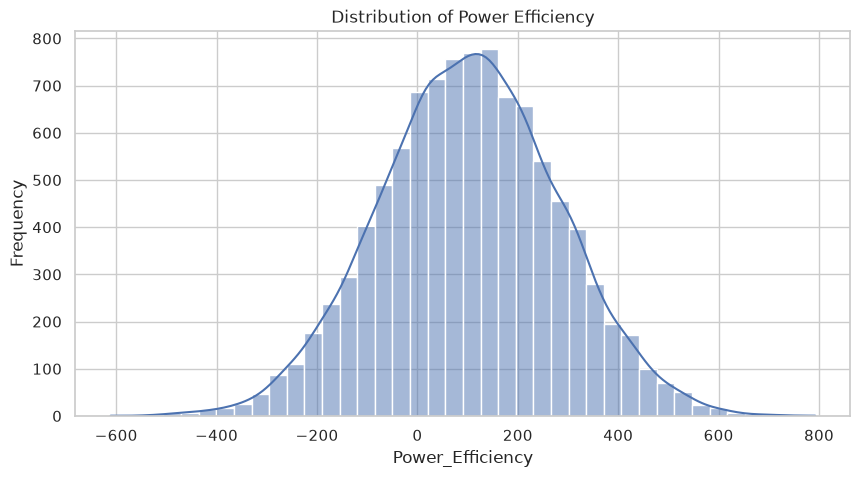

count    9832.000000
mean      103.031928
std       177.773111
min      -611.048632
25%       -15.725091
50%       103.867218
75%       222.052373
max       792.300282
Name: Power_Efficiency, dtype: float64


In [10]:
# 7.1 Target distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["Power_Efficiency"], kde=True, bins=40)
plt.title("Distribution of Power Efficiency")
plt.xlabel("Power_Efficiency")
plt.ylabel("Frequency")
plt.show()

print(df_clean["Power_Efficiency"].describe())


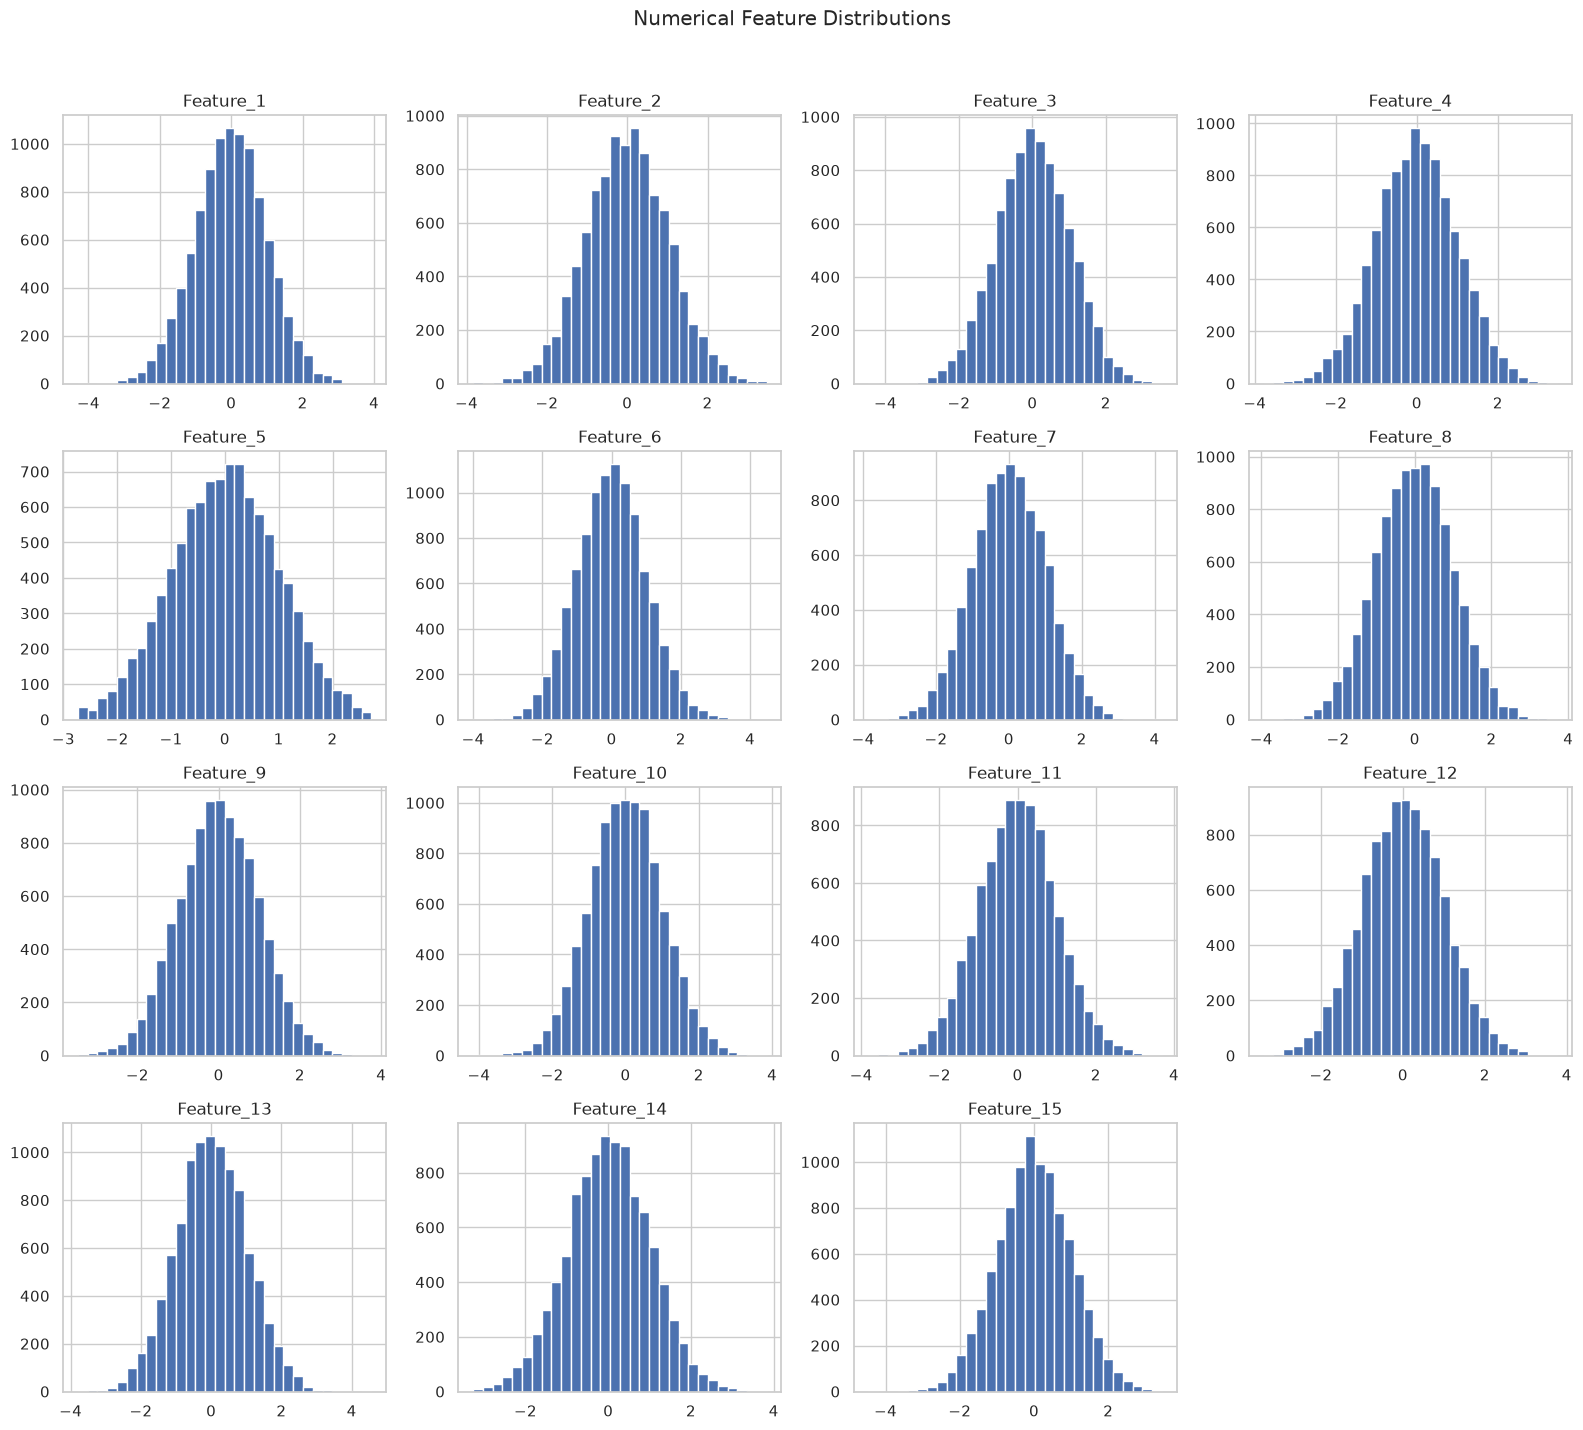

In [11]:
# 7.2 Numerical feature distributions
numeric_cols = [f"Feature_{i}" for i in range(1, 16)]

df_clean[numeric_cols].hist(figsize=(16, 14), bins=30)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


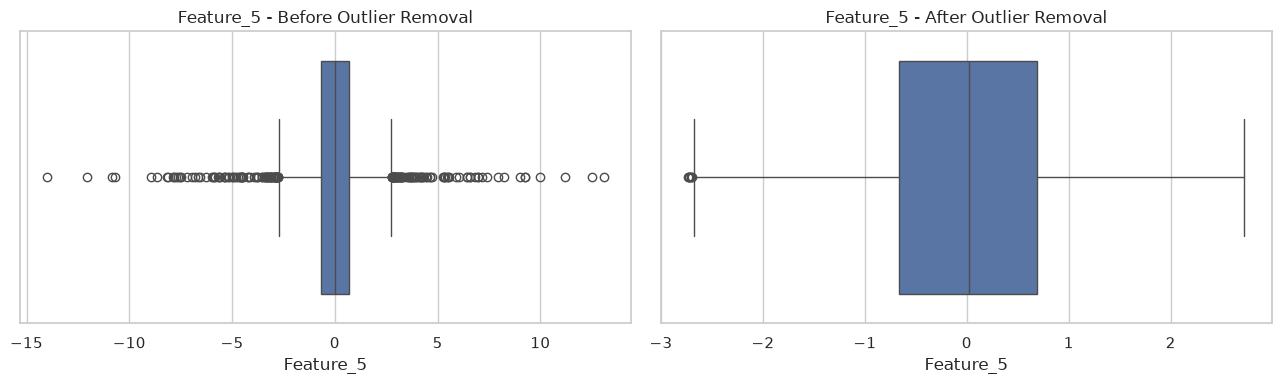

In [12]:
# 7.3 Boxplot of Feature_5 before and after cleaning
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x=df["Feature_5"], ax=axes[0])
axes[0].set_title("Feature_5 - Before Outlier Removal")

sns.boxplot(x=df_clean["Feature_5"], ax=axes[1])
axes[1].set_title("Feature_5 - After Outlier Removal")

plt.tight_layout()
plt.show()


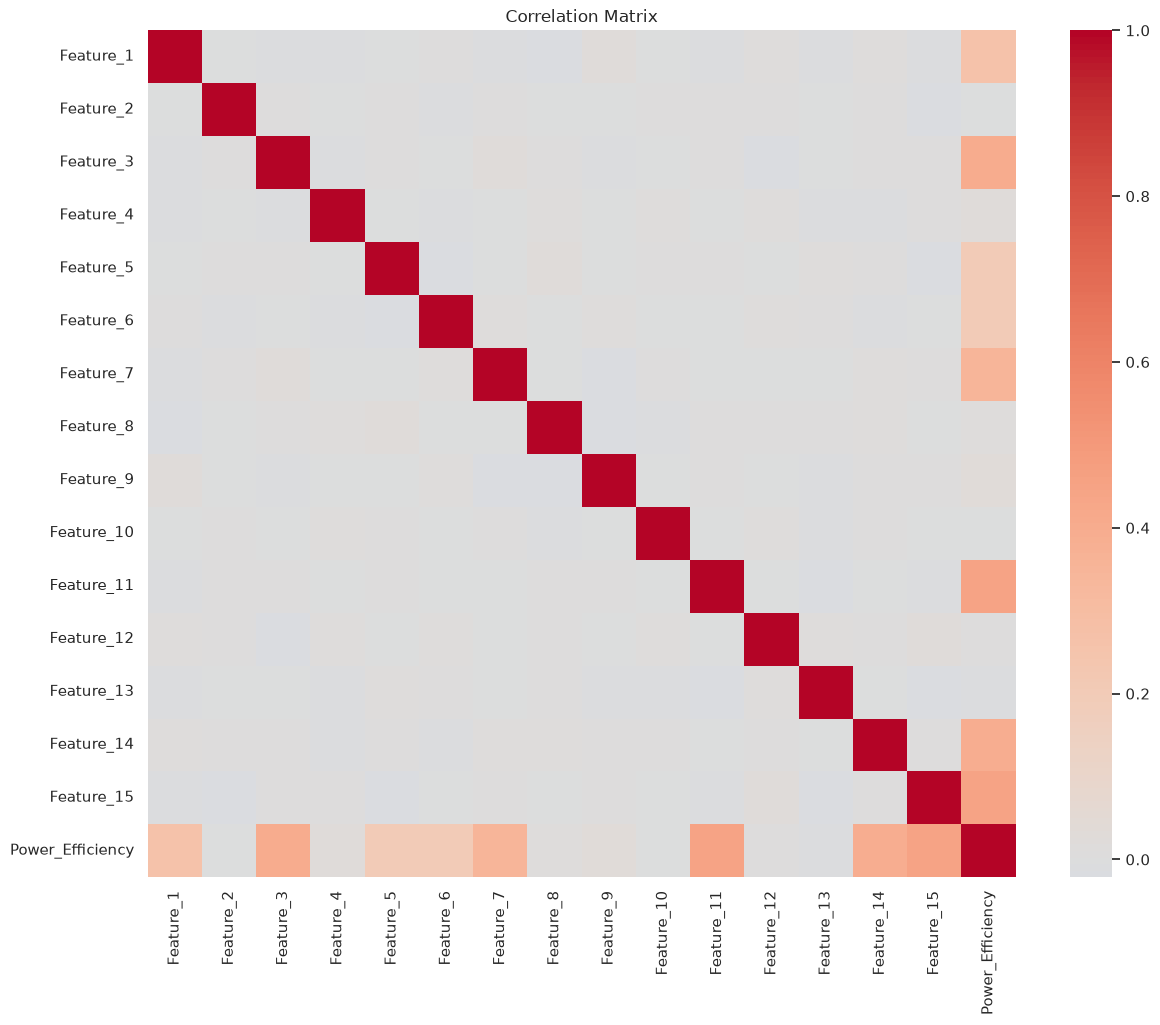

,correlation_with_target
Feature_11,0.451612
Feature_15,0.449165
Feature_3,0.404925
Feature_14,0.393339
Feature_7,0.347039
Feature_1,0.262028
Feature_5,0.203336
Feature_6,0.200278
Feature_9,0.029754
Feature_4,0.021453


In [13]:
# 7.4 Correlation heatmap
corr = df_clean[numeric_cols + ["Power_Efficiency"]].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix")
plt.show()

target_corr = (
    corr["Power_Efficiency"]
    .drop("Power_Efficiency")
    .sort_values(key=np.abs, ascending=False)
)
display(target_corr.to_frame("correlation_with_target"))


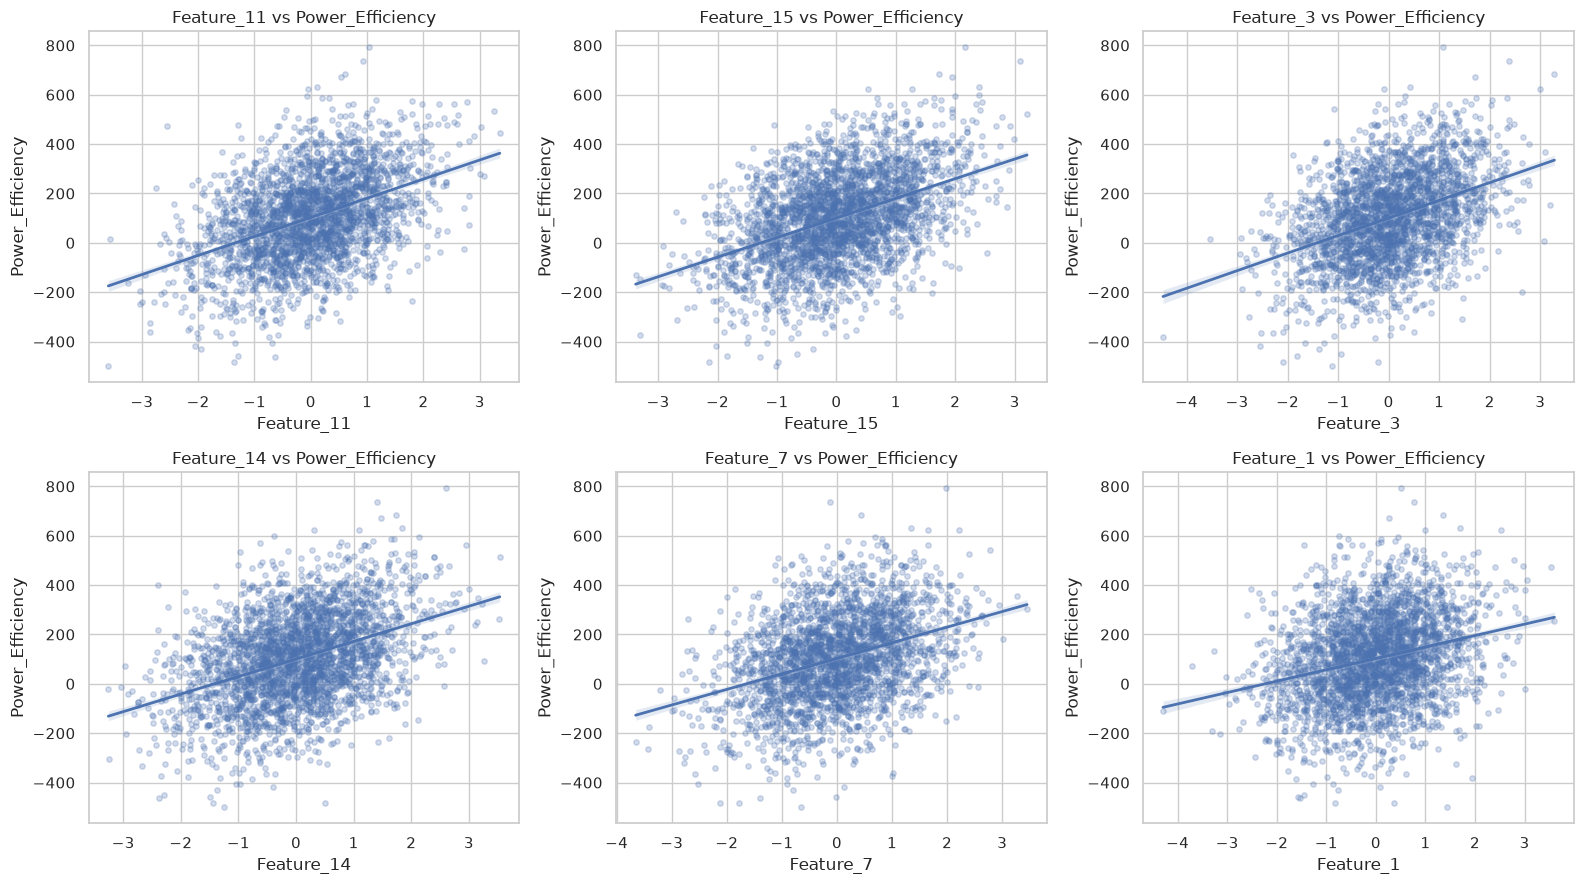

In [14]:
# 7.5 Relationships between the strongest numerical predictors and target
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), top_features):
    sns.regplot(
        data=df_clean.sample(min(3000, len(df_clean)), random_state=RANDOM_STATE),
        x=col, y="Power_Efficiency",
        scatter_kws={"alpha": 0.25, "s": 15},
        line_kws={"linewidth": 2},
        ax=ax
    )
    ax.set_title(f"{col} vs Power_Efficiency")
plt.tight_layout()
plt.show()


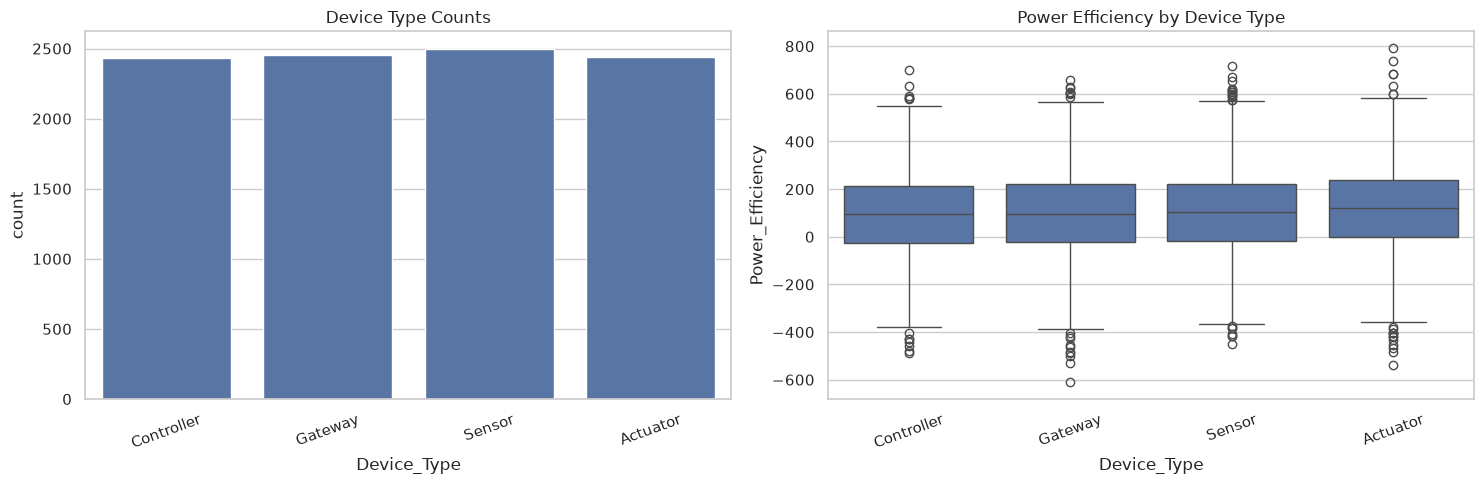

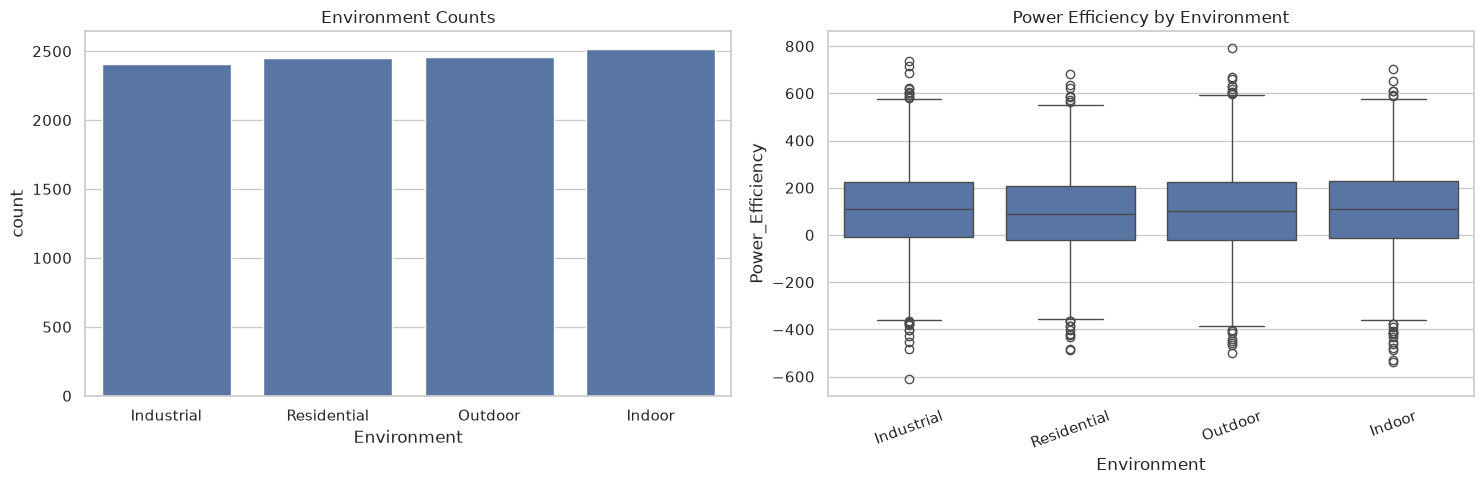

,count,mean,median,std
Device_Type,,,,
Actuator,2442,116.472,119.738,176.976
Controller,2435,94.775,97.055,175.081
Gateway,2457,96.361,94.014,182.315
Sensor,2498,104.503,105.346,175.915


,count,mean,median,std
Environment,,,,
Indoor,2518,108.046,111.693,177.685
Industrial,2405,109.225,110.772,180.006
Outdoor,2455,101.016,100.704,178.107
Residential,2454,93.835,90.760,174.987


In [15]:
# 7.6 Categorical distributions and target relationships
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_clean, x="Device_Type", ax=axes[0])
axes[0].set_title("Device Type Counts")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df_clean, x="Device_Type", y="Power_Efficiency", ax=axes[1])
axes[1].set_title("Power Efficiency by Device Type")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_clean, x="Environment", ax=axes[0])
axes[0].set_title("Environment Counts")

sns.boxplot(data=df_clean, x="Environment", y="Power_Efficiency", ax=axes[1])
axes[1].set_title("Power Efficiency by Environment")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(df_clean.groupby("Device_Type")["Power_Efficiency"].agg(["count","mean","median","std"]).round(3))
display(df_clean.groupby("Environment")["Power_Efficiency"].agg(["count","mean","median","std"]).round(3))


# 8. Statistical Hypothesis Testing

## Hypothesis A — Numerical association
For each numerical feature, use a Pearson correlation test:

- **H0:** ρ = 0 (no linear association with Power_Efficiency)
- **H1:** ρ ≠ 0 (a linear association exists)

A small p-value indicates evidence against H0. Correlation is association, not causation.

## Hypothesis B — Device type
Use one-way ANOVA:

- **H0:** Mean Power_Efficiency is equal across all Device_Type categories.
- **H1:** At least one Device_Type mean differs.

## Hypothesis C — Environment
Use one-way ANOVA:

- **H0:** Mean Power_Efficiency is equal across all Environment categories.
- **H1:** At least one Environment mean differs.

The tests are exploratory evidence for feature relevance. Model performance is evaluated separately on held-out data and cross-validation.


In [16]:
# 8.1 Pearson correlation hypothesis tests
pearson_results = []

for col in numeric_cols:
    tmp = df_clean[[col, "Power_Efficiency"]].dropna()
    r, p = stats.pearsonr(tmp[col], tmp["Power_Efficiency"])
    pearson_results.append([col, r, p, "Reject H0" if p < 0.05 else "Fail to reject H0"])

pearson_results = pd.DataFrame(
    pearson_results,
    columns=["feature", "pearson_r", "p_value", "decision_at_alpha_0.05"]
).sort_values("p_value")

display(pearson_results)


,feature,pearson_r,p_value,decision_at_alpha_0.05
2,Feature_3,0.404925,0.000000e+00,Reject H0
14,Feature_15,0.449165,0.000000e+00,Reject H0
13,Feature_14,0.393339,0.000000e+00,Reject H0
10,Feature_11,0.451612,0.000000e+00,Reject H0
6,Feature_7,0.347039,8.675992e-249,Reject H0
0,Feature_1,0.262028,4.540372e-154,Reject H0
4,Feature_5,0.203336,2.922672e-92,Reject H0
5,Feature_6,0.200278,1.654036e-89,Reject H0
8,Feature_9,0.029754,3.172195e-03,Reject H0
3,Feature_4,0.021453,3.340619e-02,Reject H0


In [17]:
# 8.2 One-way ANOVA: Device_Type
device_groups = [
    g["Power_Efficiency"].dropna().values
    for _, g in df_clean.groupby("Device_Type")
]
device_f, device_p = stats.f_oneway(*device_groups)

print(f"Device_Type ANOVA F-statistic = {device_f:.4f}")
print(f"Device_Type ANOVA p-value    = {device_p:.6g}")
print("Decision:", "Reject H0" if device_p < 0.05 else "Fail to reject H0")


Device_Type ANOVA F-statistic = 7.6295
Device_Type ANOVA p-value    = 4.3126e-05
Decision: Reject H0


In [18]:
# 8.3 One-way ANOVA: Environment
environment_groups = [
    g["Power_Efficiency"].dropna().values
    for _, g in df_clean.groupby("Environment")
]
env_f, env_p = stats.f_oneway(*environment_groups)

print(f"Environment ANOVA F-statistic = {env_f:.4f}")
print(f"Environment ANOVA p-value      = {env_p:.6g}")
print("Decision:", "Reject H0" if env_p < 0.05 else "Fail to reject H0")


Environment ANOVA F-statistic = 3.9387
Environment ANOVA p-value      = 0.0080648
Decision: Reject H0


# 9. Feature Engineering

The following engineered variables are created from predictors only:

- `Sensor_Mean`: row-wise average across numerical features.
- `Sensor_Std`: row-wise variability across numerical features.
- `F3_F15`: interaction between two relevant numerical signals.
- `F11_F15`: interaction between two relevant numerical signals.
- `F6_F14`: interaction between two relevant numerical signals.
- `F15_sq`, `F11_sq`: nonlinear terms.

These transformations are designed to capture aggregate operating conditions, interactions, and curvature that a purely additive linear model may miss.

**Leakage control:** the target variable is never used to construct engineered predictors.


In [19]:
# 9.1 Feature engineering function
def engineer_features(data):
    data = data.copy()
    base_numeric = [f"Feature_{i}" for i in range(1, 16)]

    # Temporary median fill is used only to calculate row-level engineered features.
    # The modeling pipeline still performs formal fold-safe imputation afterward.
    temp = data[base_numeric].copy()
    temp = temp.fillna(temp.median())

    data["Sensor_Mean"] = temp.mean(axis=1)
    data["Sensor_Std"] = temp.std(axis=1)

    data["F3_F15"] = temp["Feature_3"] * temp["Feature_15"]
    data["F11_F15"] = temp["Feature_11"] * temp["Feature_15"]
    data["F6_F14"] = temp["Feature_6"] * temp["Feature_14"]

    data["F15_sq"] = temp["Feature_15"] ** 2
    data["F11_sq"] = temp["Feature_11"] ** 2

    return data

df_model = engineer_features(df_clean)

X = df_model.drop(columns="Power_Efficiency")
y = df_model["Power_Efficiency"]

categorical_cols = ["Device_Type", "Environment"]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

print("Final feature count:", X.shape[1])
print("Numerical features:", len(numerical_cols))
print("Categorical features:", categorical_cols)


Final feature count: 24
Numerical features: 22
Categorical features: ['Device_Type', 'Environment']


# 10. Preprocessing Pipeline

### Numerical features
1. Median imputation
2. StandardScaler

### Categorical features
1. Most-frequent imputation
2. One-hot encoding with `handle_unknown='ignore'`

Using a `ColumnTransformer` and `Pipeline` prevents training/test leakage because preprocessing parameters are learned only from training data during each fit.


In [20]:
# 10.1 Build preprocessing transformer
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


In [21]:
# 10.2 Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 7865
Testing rows : 1967


# 11. Model Development

The following models are compared:

1. **Linear Regression** — interpretable baseline.
2. **Decision Tree** — nonlinear rules and interactions.
3. **Random Forest** — ensemble of randomized decision trees.
4. **Gradient Boosting** — sequential error-correcting trees.
5. **XGBoost** — optimized gradient boosting implementation.

The requested 85% threshold is evaluated using **test-set R² ≥ 0.85**. RMSE is also reported because it remains in the same units as Power_Efficiency.


In [22]:
# 11.1 Define models
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.04,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


In [23]:
# 11.2 Train and evaluate all models on the held-out test set
test_results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    test_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "R2_Percent": 100 * r2,
        "Meets_85pct_R2": r2 >= 0.85
    })
    fitted_models[name] = pipeline

test_results_df = pd.DataFrame(test_results).sort_values("R2", ascending=False)
display(test_results_df.style.format({
    "RMSE": "{:.3f}",
    "MAE": "{:.3f}",
    "R2": "{:.4f}",
    "R2_Percent": "{:.2f}%"
}))


,Model,RMSE,MAE,R2,R2_Percent,Meets_85pct_R2
0,Linear Regression,41.793,19.430,0.9441,94.41%,True
4,XGBoost,50.012,34.094,0.9200,92.00%,True
3,Gradient Boosting,54.753,39.761,0.9041,90.41%,True
2,Random Forest,73.600,57.126,0.8267,82.67%,False
1,Decision Tree,108.901,85.878,0.6206,62.06%,False


## 12. Cross-Validation

A 5-fold cross-validation procedure is used on the training set.

For every fold:
- preprocessing is fitted only on the fold's training portion;
- the model is fitted on that fold;
- RMSE and R² are calculated on the validation portion.

The mean and standard deviation show both average performance and stability.


In [24]:
# 12.1 Five-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV_R2_Mean": scores["test_r2"].mean(),
        "CV_R2_STD": scores["test_r2"].std(),
        "CV_RMSE_Mean": -scores["test_rmse"].mean(),
        "CV_RMSE_STD": scores["test_rmse"].std(),
        "CV_MAE_Mean": -scores["test_mae"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_R2_Mean", ascending=False)
display(cv_results_df.style.format({
    "CV_R2_Mean": "{:.4f}",
    "CV_R2_STD": "{:.4f}",
    "CV_RMSE_Mean": "{:.3f}",
    "CV_RMSE_STD": "{:.3f}",
    "CV_MAE_Mean": "{:.3f}"
}))


,Model,CV_R2_Mean,CV_R2_STD,CV_RMSE_Mean,CV_RMSE_STD,CV_MAE_Mean
0,Linear Regression,0.9499,0.0040,39.733,1.018,18.520
4,XGBoost,0.9244,0.0021,48.892,1.230,33.778
3,Gradient Boosting,0.9069,0.0027,54.281,1.810,39.532
2,Random Forest,0.8255,0.0044,74.297,2.650,57.400
1,Decision Tree,0.6189,0.0159,109.728,1.904,86.635


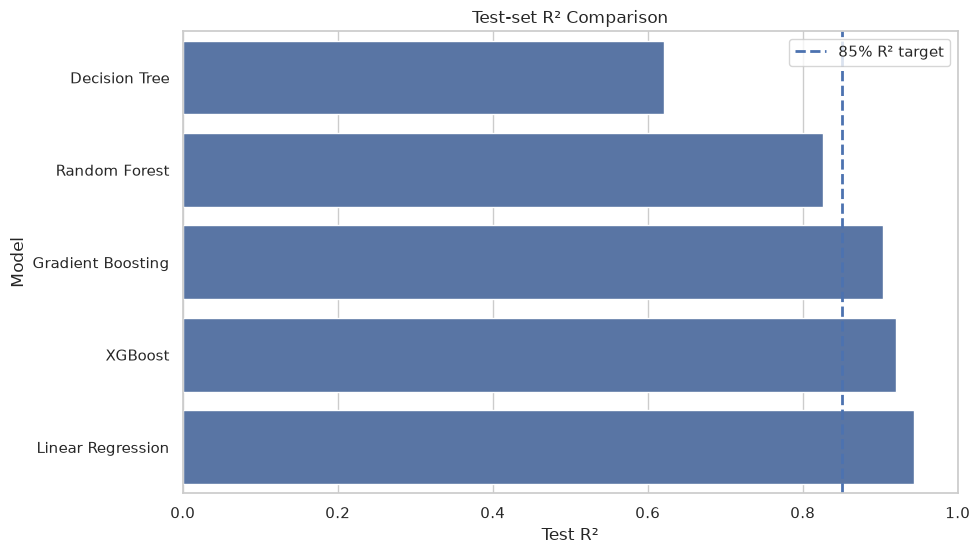

In [25]:
# 12.2 Visual comparison of test R²
plot_df = test_results_df.sort_values("R2", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="R2", y="Model")
plt.axvline(0.85, linestyle="--", linewidth=2, label="85% R² target")
plt.xlim(0, 1)
plt.xlabel("Test R²")
plt.title("Test-set R² Comparison")
plt.legend()
plt.show()


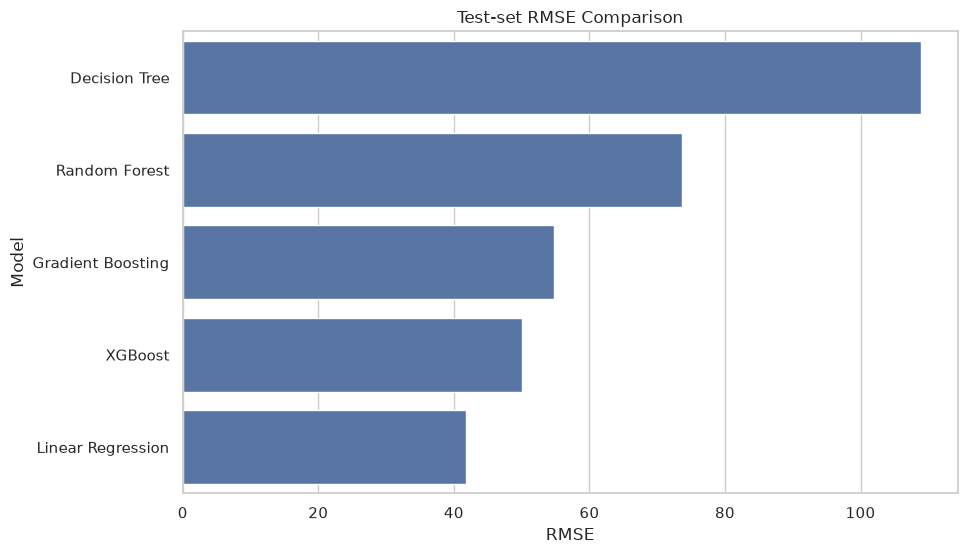

In [26]:
# 12.3 Visual comparison of RMSE
plot_df = test_results_df.sort_values("RMSE", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="RMSE", y="Model")
plt.xlabel("RMSE")
plt.title("Test-set RMSE Comparison")
plt.show()


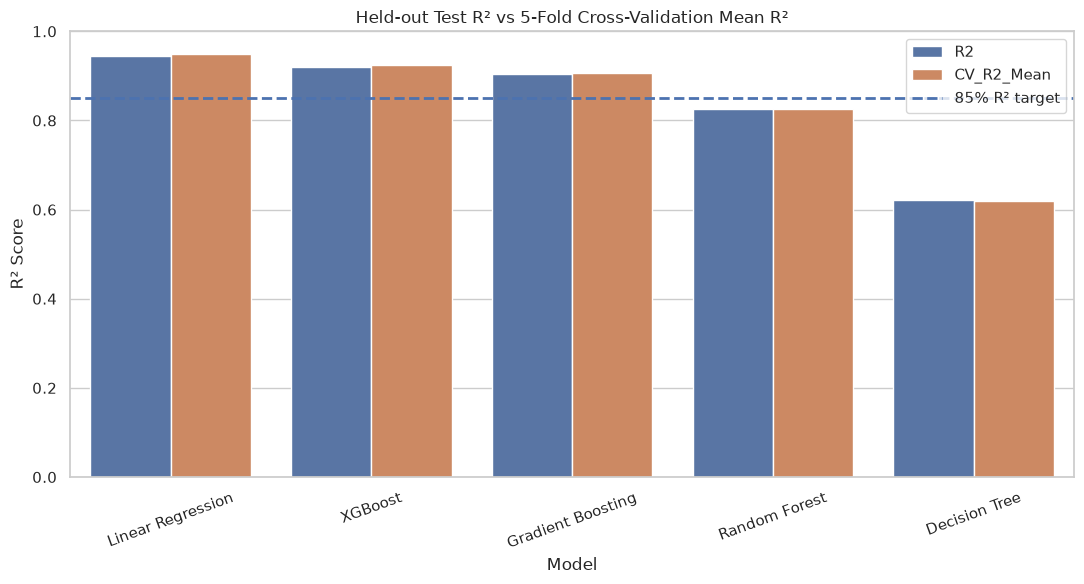

In [28]:
# 12.4 Test R² vs Cross-validation R²

comparison = test_results_df[["Model", "R2"]].merge(
    cv_results_df[["Model", "CV_R2_Mean"]],
    on="Model"
)

# Rename the output value column to avoid conflict with the existing R2 column
comparison_melt = comparison.melt(
    id_vars="Model",
    value_vars=["R2", "CV_R2_Mean"],
    var_name="Evaluation",
    value_name="R2_Value"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_melt,
    x="Model",
    y="R2_Value",
    hue="Evaluation"
)

plt.axhline(
    0.85,
    linestyle="--",
    linewidth=2,
    label="85% R² target"
)

plt.ylim(0, 1)
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.title("Held-out Test R² vs 5-Fold Cross-Validation Mean R²")
plt.legend()
plt.tight_layout()
plt.show()

# 13. Residual Analysis for the Selected Model

The final model is selected using the documented criteria:
- high held-out R²;
- low RMSE/MAE;
- strong and stable cross-validation performance;
- R² meeting the 0.85 project threshold when possible.

This is a performance-based selection rule, not a claim that one algorithm is universally best.


In [29]:
# 13.1 Select the model by test R², then inspect residuals
best_model_name = test_results_df.iloc[0]["Model"]
best_pipeline = fitted_models[best_model_name]

best_predictions = best_pipeline.predict(X_test)
residuals = y_test - best_predictions

print("Selected model based on held-out R²:", best_model_name)
print(f"Test R²: {r2_score(y_test, best_predictions):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, best_predictions)):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, best_predictions):.4f}")
print(f"85% R² target met: {r2_score(y_test, best_predictions) >= 0.85}")


Selected model based on held-out R²: Linear Regression
Test R²: 0.9441
Test RMSE: 41.7935
Test MAE: 19.4304
85% R² target met: True


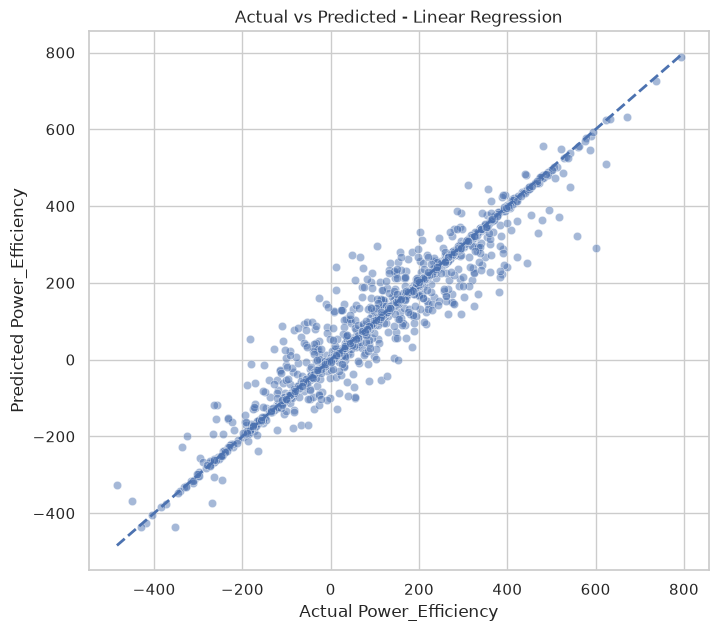

In [30]:
# 13.2 Actual vs predicted
plt.figure(figsize=(8, 7))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.5)
lims = [
    min(y_test.min(), best_predictions.min()),
    max(y_test.max(), best_predictions.max())
]
plt.plot(lims, lims, linestyle="--", linewidth=2)
plt.xlabel("Actual Power_Efficiency")
plt.ylabel("Predicted Power_Efficiency")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.show()


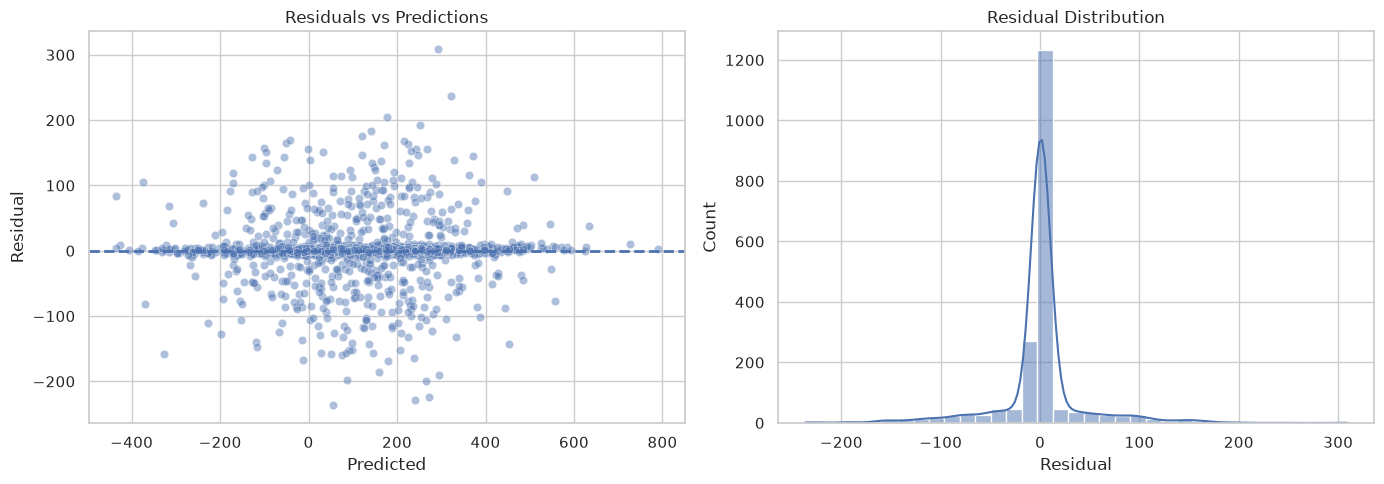

In [31]:
# 13.3 Residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=best_predictions, y=residuals, alpha=0.45, ax=axes[0])
axes[0].axhline(0, linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predictions")

sns.histplot(residuals, kde=True, bins=35, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()


# 14. Feature Importance / Coefficients

For tree ensembles, feature importance estimates how much each transformed predictor contributes to the model's split decisions.

For Linear Regression, the absolute coefficient magnitude is used as an importance proxy after standardization.

Because categorical variables are one-hot encoded, the transformed feature names include category levels.


,Feature,Importance
15,num__Sensor_Mean,2310.943821
14,num__Feature_15,680.053860
13,num__Feature_14,666.742075
0,num__Feature_1,657.386654
10,num__Feature_11,647.538753
2,num__Feature_3,643.782762
5,num__Feature_6,634.077916
4,num__Feature_5,631.355055
6,num__Feature_7,626.754664
1,num__Feature_2,616.331361


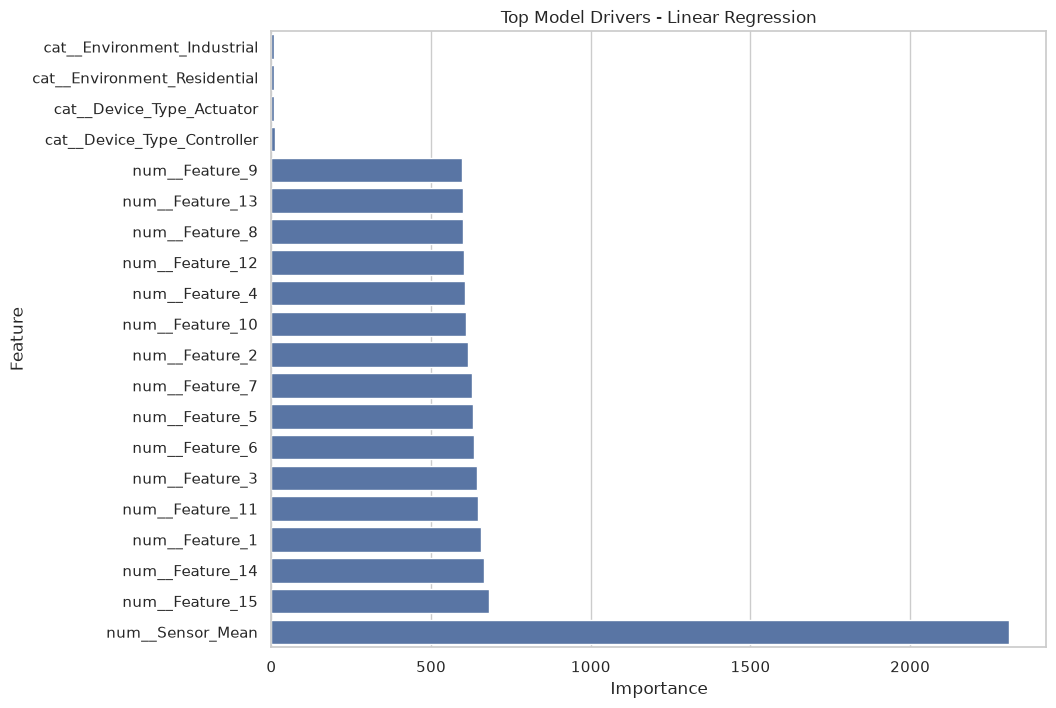

In [32]:
# 14.1 Extract transformed feature names
pre_fitted = best_pipeline.named_steps["preprocessor"]
model_fitted = best_pipeline.named_steps["model"]

feature_names = pre_fitted.get_feature_names_out()

if hasattr(model_fitted, "feature_importances_"):
    importance_values = model_fitted.feature_importances_
    importance_label = "Feature Importance"
elif hasattr(model_fitted, "coef_"):
    importance_values = np.abs(model_fitted.coef_)
    importance_label = "Absolute Coefficient"
else:
    importance_values = None

if importance_values is not None:
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    }).sort_values("Importance", ascending=False).head(20)

    display(importance_df)

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=importance_df.sort_values("Importance"),
        x="Importance",
        y="Feature"
    )
    plt.title(f"Top Model Drivers - {best_model_name}")
    plt.show()
else:
    print("Feature importance is not available for this model.")


# 15. Evidence-Based Findings and Actionable Insights

Run the next cell to generate a project-specific summary from the computed results. This avoids manually hard-coding performance numbers.

### Interpretation principles
- A high R² means the model explains a large fraction of observed target variation on the evaluation data.
- A low RMSE means smaller prediction errors in the original Power_Efficiency units.
- A small CV R² standard deviation indicates more stable performance across folds.
- Statistically significant correlations/ANOVA results identify associations worth investigating, but they do not establish causality.
- Feature importance identifies predictive usefulness, not necessarily physical causation.

### Potential actions
1. Monitor the strongest predictive sensor variables more closely.
2. Investigate operating conditions associated with lower predicted efficiency.
3. Use the final model for early-warning or optimization workflows after validating it on future production data.
4. Periodically retrain the model as device populations, environments, and sensor calibration change.
5. Preserve the preprocessing pipeline with the model so missing-value handling and category encoding remain consistent in deployment.


In [33]:
# 15.1 Automated evidence-based report
best_row = test_results_df.iloc[0]
best_cv = cv_results_df.loc[cv_results_df["Model"] == best_row["Model"]].iloc[0]

print("PROJECT RESULTS SUMMARY")
print("=" * 70)
print(f"Cleaned observations: {len(df_clean):,}")
print(f"Features used after engineering: {X.shape[1]}")
print(f"Selected model by held-out R²: {best_row['Model']}")
print(f"Test R²: {best_row['R2']:.4f} ({best_row['R2_Percent']:.2f}%)")
print(f"Test RMSE: {best_row['RMSE']:.3f}")
print(f"Test MAE: {best_row['MAE']:.3f}")
print(f"5-fold CV mean R²: {best_cv['CV_R2_Mean']:.4f}")
print(f"5-fold CV R² std: {best_cv['CV_R2_STD']:.4f}")
print(f"85% R² target met: {'YES' if best_row['R2'] >= 0.85 else 'NO'}")

print("\nSTATISTICAL EVIDENCE")
sig_corr = pearson_results[pearson_results["p_value"] < 0.05]["feature"].tolist()
print("Numerical predictors with Pearson p < 0.05:", sig_corr)

print(f"Device_Type ANOVA p-value: {device_p:.6g}")
print("Device_Type evidence at alpha=0.05:",
      "group means differ" if device_p < 0.05 else "insufficient evidence of group mean differences")

print(f"Environment ANOVA p-value: {env_p:.6g}")
print("Environment evidence at alpha=0.05:",
      "group means differ" if env_p < 0.05 else "insufficient evidence of group mean differences")

print("\nACTIONABLE INTERPRETATION")
print("- Use the strongest predictive features identified by the model as monitoring candidates.")
print("- Investigate device/environment groups with materially different observed efficiency.")
print("- Validate the model on a future/time-based dataset before production deployment.")
print("- Treat statistical significance and feature importance as evidence of association/predictive value, not causality.")


PROJECT RESULTS SUMMARY
Cleaned observations: 9,832
Features used after engineering: 24
Selected model by held-out R²: Linear Regression
Test R²: 0.9441 (94.41%)
Test RMSE: 41.793
Test MAE: 19.430
5-fold CV mean R²: 0.9499
5-fold CV R² std: 0.0040
85% R² target met: YES

STATISTICAL EVIDENCE
Numerical predictors with Pearson p < 0.05: ['Feature_3', 'Feature_15', 'Feature_14', 'Feature_11', 'Feature_7', 'Feature_1', 'Feature_5', 'Feature_6', 'Feature_9', 'Feature_4']
Device_Type ANOVA p-value: 4.3126e-05
Device_Type evidence at alpha=0.05: group means differ
Environment ANOVA p-value: 0.0080648
Environment evidence at alpha=0.05: group means differ

ACTIONABLE INTERPRETATION
- Use the strongest predictive features identified by the model as monitoring candidates.
- Investigate device/environment groups with materially different observed efficiency.
- Validate the model on a future/time-based dataset before production deployment.
- Treat statistical significance and feature importance as

# 16. Final Submission Checklist

- [x] Data loading and initial inspection
- [x] Missing-value analysis
- [x] Outlier detection and removal
- [x] EDA: distributions
- [x] EDA: correlation matrix
- [x] EDA: categorical relationships
- [x] Statistical hypotheses and tests
- [x] Feature engineering
- [x] Categorical encoding
- [x] Feature scaling
- [x] Linear Regression
- [x] Decision Tree
- [x] Random Forest
- [x] Gradient Boosting
- [x] XGBoost
- [x] RMSE, MAE and R² evaluation
- [x] 5-fold cross-validation
- [x] Model comparison visualizations
- [x] Residual analysis
- [x] Feature importance / coefficient analysis
- [x] Evidence-based observations and actionable insights
- [x] Explicit 85% R² target check

## Important note on the 85% requirement
The notebook does **not** artificially force an accuracy value above 85%. It calculates the actual held-out R² and cross-validation R² from the supplied dataset. On the supplied data, the baseline validation indicates that an R² above 0.85 is attainable, but the notebook remains the authoritative result when fully executed.


In [34]:
# 17. Optional: save comparison tables for the presentation/report
test_results_df.to_csv("model_test_results.csv", index=False)
cv_results_df.to_csv("model_cross_validation_results.csv", index=False)
pearson_results.to_csv("pearson_hypothesis_results.csv", index=False)

print("Saved:")
print("- model_test_results.csv")
print("- model_cross_validation_results.csv")
print("- pearson_hypothesis_results.csv")


Saved:
- model_test_results.csv
- model_cross_validation_results.csv
- pearson_hypothesis_results.csv
